In [1]:

import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sdata = spatialdata_io.visium_hd('../data/Visium_HD_Liver_CAW009/')

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_165804/4034718418.py:1: UserWarning: Multiple fil

In [3]:
sdata

SpatialData object
├── Images
│     ├── 'CAW009_hires_image': DataArray[cyx] (3, 6000, 4747)
│     └── 'CAW009_lowres_image': DataArray[cyx] (3, 600, 475)
├── Labels
│     ├── 'CAW009_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'CAW009_square_008um_labels': DataArray[yx] (838, 838)
│     ├── 'CAW009_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'CAW009_square_032um_labels': DataArray[yx] (210, 210)
├── Shapes
│     ├── 'CAW009_square_002um': GeoDataFrame shape: (6931516, 1) (2D shapes)
│     ├── 'CAW009_square_008um': GeoDataFrame shape: (437010, 1) (2D shapes)
│     ├── 'CAW009_square_016um': GeoDataFrame shape: (110518, 1) (2D shapes)
│     └── 'CAW009_square_032um': GeoDataFrame shape: (28319, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (6931516, 19059)
      ├── 'square_008um': AnnData (437010, 19059)
      ├── 'square_016um': AnnData (110518, 19059)
      └── 'square_032um': AnnData (28319, 19059)
with coordinate systems:
    ▸ 'downscaled

In [17]:
# Save shape objects
for bin_size in [8, 16, 32]:
    sdata.tables[f'square_{bin_size:03}um'].obs.to_csv(f'../visium_hd_liver_combined/rds/shapes/CAW009_square_{bin_size:03}um_locationid.csv')
    sdata.shapes[f'CAW009_square_{bin_size:03}um'].to_file(f'../visium_hd_liver_combined/rds/shapes/CAW009_square_{bin_size:03}um.shp')

/tmp/ipykernel_165804/2481642004.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sdata.shapes[f'CAW009_square_{bin_size:03}um'].to_file(f'../visium_hd_liver_combined/rds/shapes/CAW009_square_{bin_size:03}um.shp')
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'location_id' to 'location_i'
  ogr_write(
/tmp/ipykernel_165804/2481642004.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sdata.shapes[f'CAW009_square_{bin_size:03}um'].to_file(f'../visium_hd_liver_combined/rds/shapes/CAW009_square_{bin_size:03}um.shp')
/home/chananchidas/minico

/tmp/ipykernel_165804/1261339092.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sdata.shapes['CAW009_square_008um'].to_file('../visium_hd_liver_combined/rds/shapes/CAW009_square_008um.shp')
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'location_id' to 'location_i'
  ogr_write(


INFO     Rasterizing image for faster rendering.                                                                   


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.125..1.0].


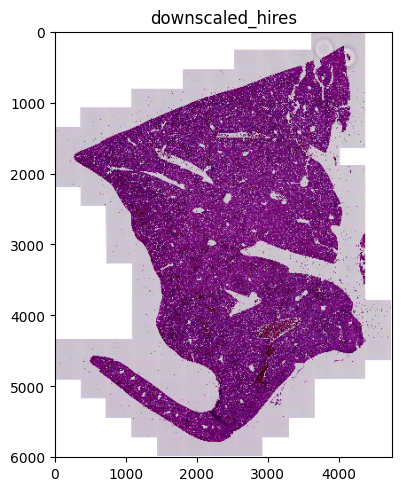

In [4]:
sdata.pl.render_images("CAW009_hires_image").pl.show(coordinate_systems="downscaled_hires")

In [4]:
bin_sizes = [2, 8, 16, 32]

for bin_size in bin_sizes:
    bin_name = "square_{:03d}um".format(bin_size)
    # Get average counts per bin
    print("Average counts per {}um bin:".format(bin_size), end=" ")
    print(sdata.tables[bin_name].X.sum(axis=1).mean())

    # Get average number of genes per bin
    print("Average number of genes per {}um bin:".format(bin_size), end=" ")
    print(sdata.tables[bin_name].X.astype(bool).sum(axis=1).mean())

Average counts per 2um bin: 104.91124
Average number of genes per 2um bin: 69.38188961837497
Average counts per 8um bin: 1668.083
Average number of genes per 8um bin: 726.930514175877
Average counts per 16um bin: 6612.533
Average number of genes per 16um bin: 2002.9996742612063
Average counts per 32um bin: 25904.723
Average number of genes per 32um bin: 4506.496239273985


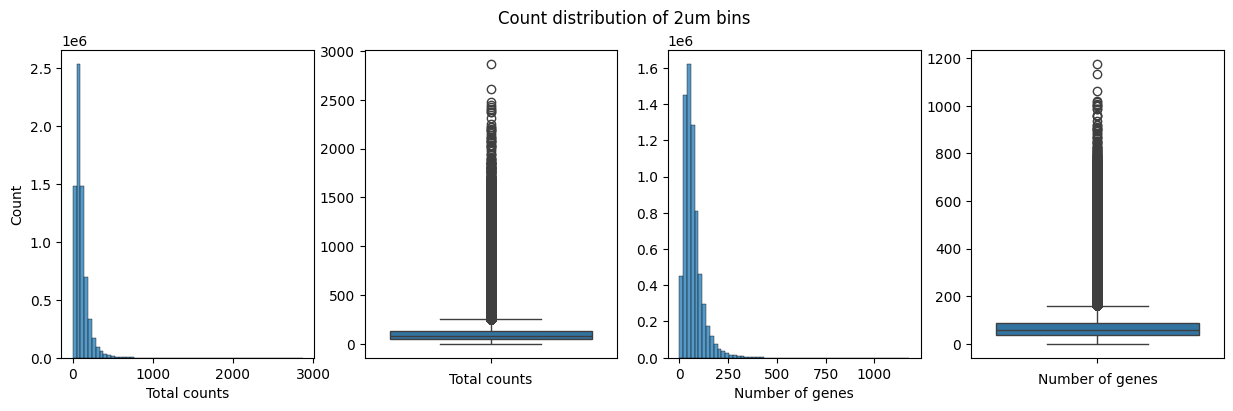

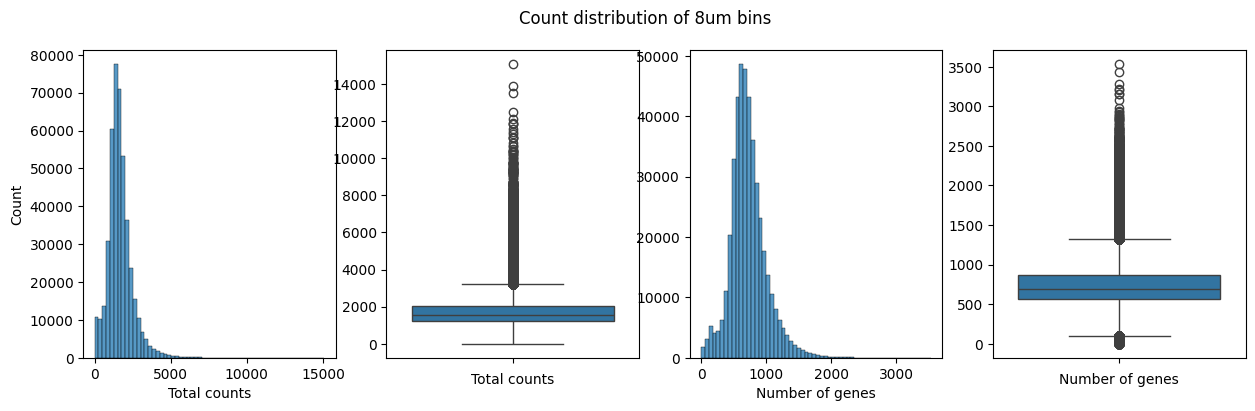

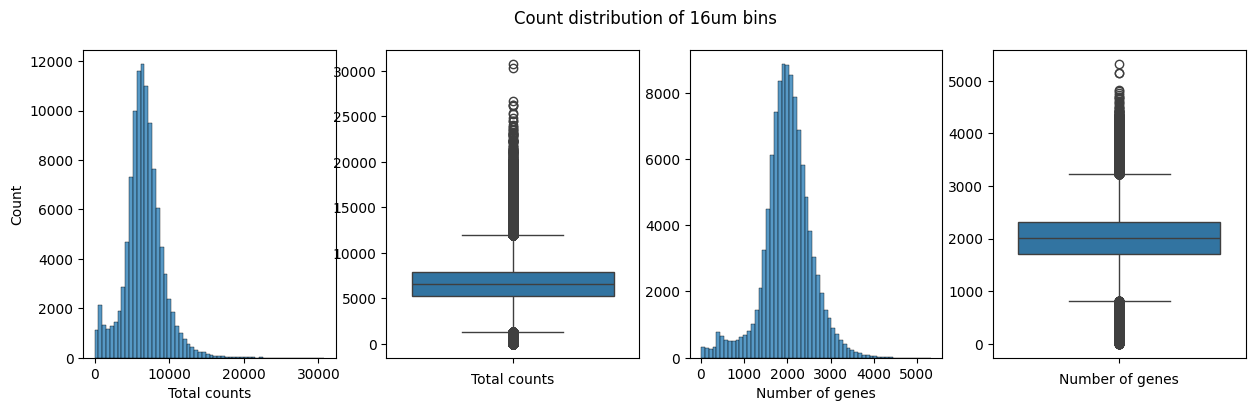

In [6]:
for bin_size in bin_sizes:
    bin_name = "square_{:03d}um".format(bin_size)
    
    # Count distribution per bin size
    adata = sdata.tables[bin_name]
    adata.obs["total_counts"] = adata.X.sum(axis=1)
    adata.obs["n_genes_by_counts"] = (adata.X > 0).sum(axis=1)

    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
    
    sns.boxplot(adata.obs["total_counts"], ax=axs[1])
    # sns.histplot(
    #     adata.obs["total_counts"][adata.obs["total_counts"] < 1000],
    #     kde=False,
    #     bins=40,
    #     ax=axs[1],
    # )
    sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
    sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])
    # sns.histplot(
    #     adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 500],
    #     kde=False,
    #     bins=60,
    #     ax=axs[3],
    # )

    # Set overall title
    fig.suptitle("Count distribution of {}um bins".format(bin_size))

    # Set title and labels
    axs[0].set_xlabel("Total counts")
    axs[1].set_xlabel("Total counts")
    axs[2].set_xlabel("Number of genes")
    axs[3].set_xlabel("Number of genes")

    # Turn off y-axis title
    axs[1].set_ylabel("")
    axs[2].set_ylabel("")
    axs[3].set_ylabel("")
    
    # Save plot
    plt.savefig("plots/histogram_count_genes_{}um.png".format(bin_size), dpi=300)


In [7]:
'Clec4f' in sdata.tables['square_008um'].var_names

True

### Clec4f expression

In [4]:
adata = sdata.tables['square_008um']

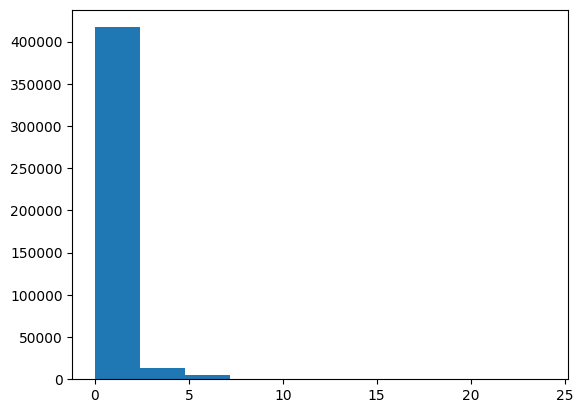

In [5]:
# Get distribution of Hnrnpa1 expression in adata
gene = adata.X[:, adata.var_names == 'Clec4f']

# Convert to vector
gene = gene.toarray().reshape(-1)

# plot histogram
import matplotlib.pyplot as plt
plt.hist(gene, bins=10)
plt.show()


In [6]:
# Count number of cells with Hnrnpa1 expression > 0
num_cells = sum(gene > 0)
num_cells

101000

In [7]:
# Create dataframe from the vector
import pandas as pd
df = pd.DataFrame(gene, columns=['Clec4f'])

In [8]:
df['Clec4f'].describe()

count    437010.000000
mean          0.431002
std           1.086543
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.000000
Name: Clec4f, dtype: float64

In [9]:
df['Clec4f'].value_counts()

Clec4f
0.0     336010
1.0      61256
2.0      19648
3.0       8920
4.0       4716
5.0       2613
6.0       1532
7.0        881
8.0        553
9.0        332
10.0       220
11.0       129
12.0        76
13.0        52
14.0        32
15.0        14
17.0         7
16.0         6
18.0         5
19.0         3
21.0         2
24.0         2
23.0         1
Name: count, dtype: int64

In [14]:
# let's make the var names unique; this improves performance in accessing the tabular data and is necessary to be able to plot the data
for table in sdata.tables.values():
    table.var_names_make_unique()

In [15]:
sdata

SpatialData object
├── Images
│     ├── 'CAW009_hires_image': DataArray[cyx] (3, 6000, 4747)
│     └── 'CAW009_lowres_image': DataArray[cyx] (3, 600, 475)
├── Labels
│     ├── 'CAW009_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'CAW009_square_008um_labels': DataArray[yx] (838, 838)
│     ├── 'CAW009_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'CAW009_square_032um_labels': DataArray[yx] (210, 210)
├── Shapes
│     ├── 'CAW009_square_002um': GeoDataFrame shape: (6931516, 1) (2D shapes)
│     ├── 'CAW009_square_008um': GeoDataFrame shape: (437010, 1) (2D shapes)
│     ├── 'CAW009_square_016um': GeoDataFrame shape: (110518, 1) (2D shapes)
│     └── 'CAW009_square_032um': GeoDataFrame shape: (28319, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (6931516, 19059)
      ├── 'square_008um': AnnData (437010, 19059)
      ├── 'square_016um': AnnData (110518, 19059)
      └── 'square_032um': AnnData (28319, 19059)
with coordinate systems:
    ▸ 'downscaled

INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


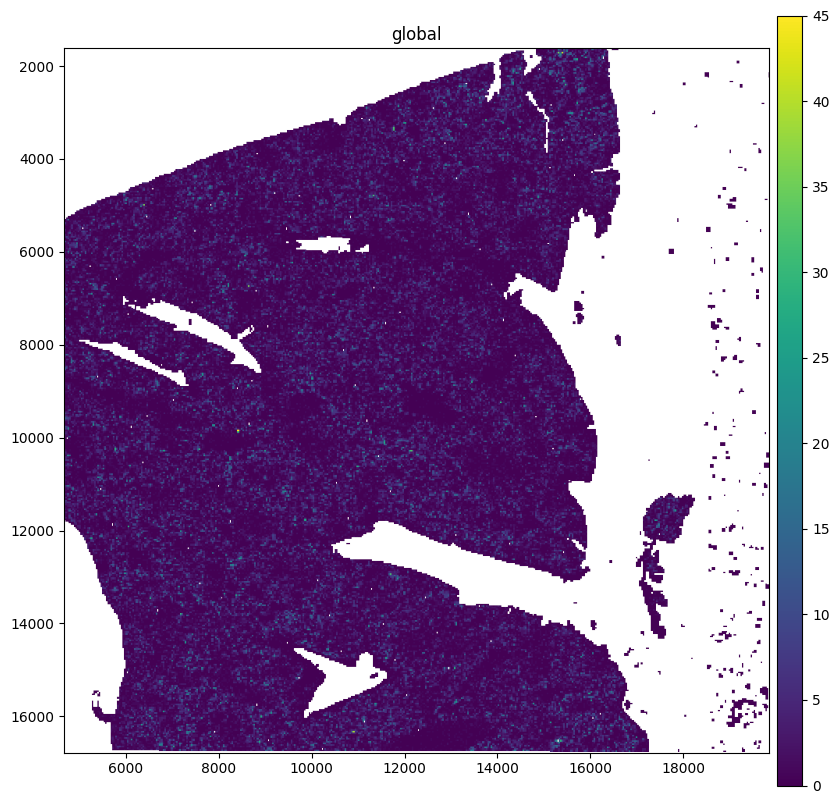

In [16]:
# Plot Hnrnpa1 expression on the spatial data
plt.figure(figsize=(10, 10))
ax = plt.gca()

gene_name = "Clec4f"
sdata.pl.render_shapes("CAW009_square_016um", color=gene_name, method="datashader").pl.show(
    coordinate_systems="global", ax=ax
)


In [19]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[2000, 2000], max_coordinate=[3000, 3000], axes=("x", "y"), target_coordinate_system="downscaled_hires"
)

sdata_small.tables['square_008um'].var_names_make_unique()


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using 'datashader' backend with 'sum' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   
INFO     Using the datashader reduction "sum". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


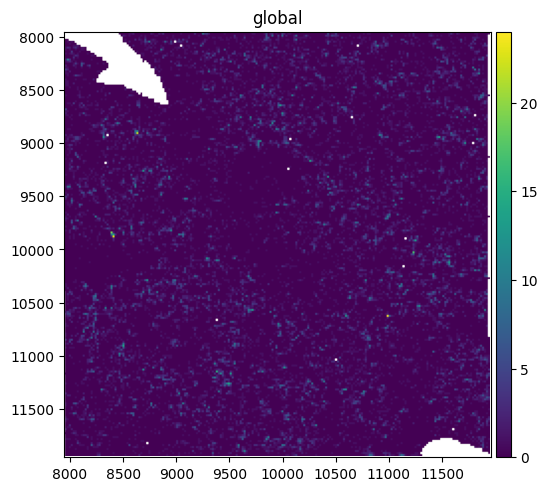

In [20]:
gene_name = "Clec4f"
sdata_small.pl.render_shapes("CAW009_square_008um", color=gene_name, method="datashader").pl.show(
    coordinate_systems="global"
)